# Generate and inspect some example detector arrays

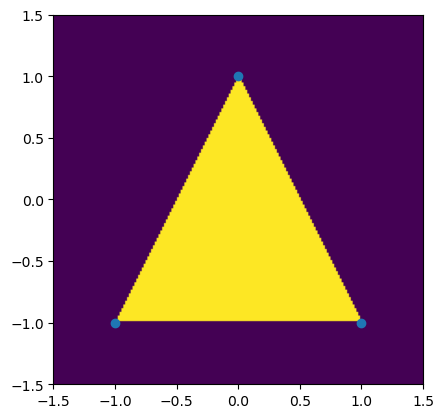

In [7]:
from matplotlib import pyplot as plt
from subshowers import detector, showers, subshowers, responses
import matplotlib
import numpy as np
import os

edges = np.zeros((1, 3, 3))
edges[0, 0] = [0, 1, 0]
edges[0, 1] = [-1, -1, 0]
edges[0, 2] = [1, -1, 0]
simple_triangles = detector.Triangles(edges)

simple_grid, _, _ = detector.grid_positions(simple_triangles, grid_center=np.array((0, 0, 0)), grid_size=3, bins=200)
plt.imshow(simple_grid, extent=[-1.5, 1.5, -1.5, 1.5], origin='lower')
plt.scatter(edges[:, :, 0].flatten(), edges[:, :, 1].flatten())

skip_long = False

array([-1071.65194474,  1083.19185355, -1124.02411935,  1030.81967893])

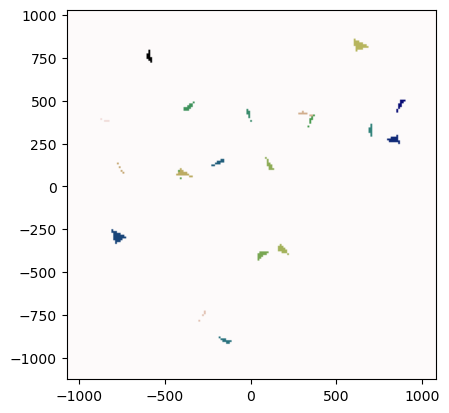

In [2]:
triangles = detector.generate_at_ground(20, mean_width=100)
grid, grid_center, grid_size = detector.grid_positions(triangles, bins=200)

def plot_grid(grid, grid_center, grid_size, **kwargs):
    extent = np.full(4, grid_size/2)
    extent[[0, 2]] *= -1
    extent[[0, 1]] += grid_center[0]
    extent[[2, 3]] += grid_center[1]
    plt.imshow(grid, extent=extent, origin='lower', **kwargs)
    return extent

plot_grid(*detector.grid_positions(triangles, bins=200), cmap='gist_earth_r')

In [5]:
if not skip_long:
    import yaml
    conf_path = "subshowers/configs/default.yaml"
    with open(conf_path, 'r') as f:
        conf = yaml.safe_load(f)
    
    shower_files = showers.ShowerFolders(conf)
    print(f"Found {len(shower_files)} showers")
    reader = showers.Reader(shower_files[0])
    print(f"Shower with {len(reader)} tracks")
    subshower_energy = 500 #9000
    subshower_path = os.path.join(shower_files[0], f"subshowers_e{subshower_energy}.h5")
    outputs = subshowers.Output.load(subshower_path)
    n_subshowers = len(outputs.shower_starts)
    print(f"Found {n_subshowers} subshowers at starting energy {subshower_energy}")
    start_energy = []
    for start_idx, sub in outputs.subshowers:
        start_energy.append(reader.data["kinetic_energy"][start_idx])

Found 4 showers
Shower with 4829167 tracks
Found 257 subshowers at starting energy 500


249
Got deposits
101
Got deposits
8
Got deposits
16
Got deposits


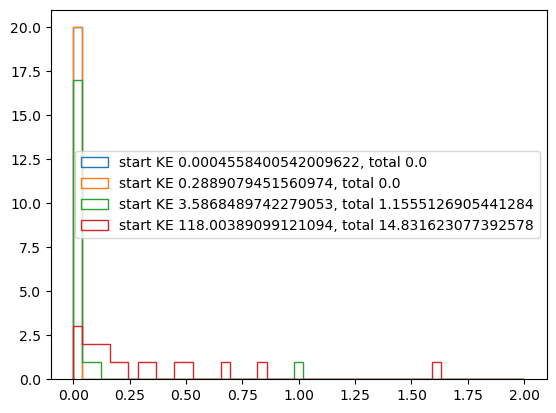

In [9]:
if not skip_long:
    to_plot = [int(np.floor(p*(n_subshowers-1))) for p in [0.1, 0.5, 0.9, 1]]
    to_plot = np.argsort(start_energy)[to_plot][::-1]
    
    deposits = []
    start_ke = []
    n_leaves = []
    
    for subshower_idx in to_plot:
        print(subshower_idx)
        start_idx, subshower_leaves = outputs.subshowers[subshower_idx]
        energy_per_detector = responses.sample_energy(reader, subshower_leaves, triangles)
        deposits.append(energy_per_detector)
        print("Got deposits")
        start_ke.append(reader.data["kinetic_energy"][start_idx])
        n_leaves.append(len(subshower_leaves))
        plt.hist(energy_per_detector, histtype='step', bins=np.linspace(0, 2, 50), label=f"start KE {start_ke[-1]}, total {np.sum(energy_per_detector)}")
    plt.legend()

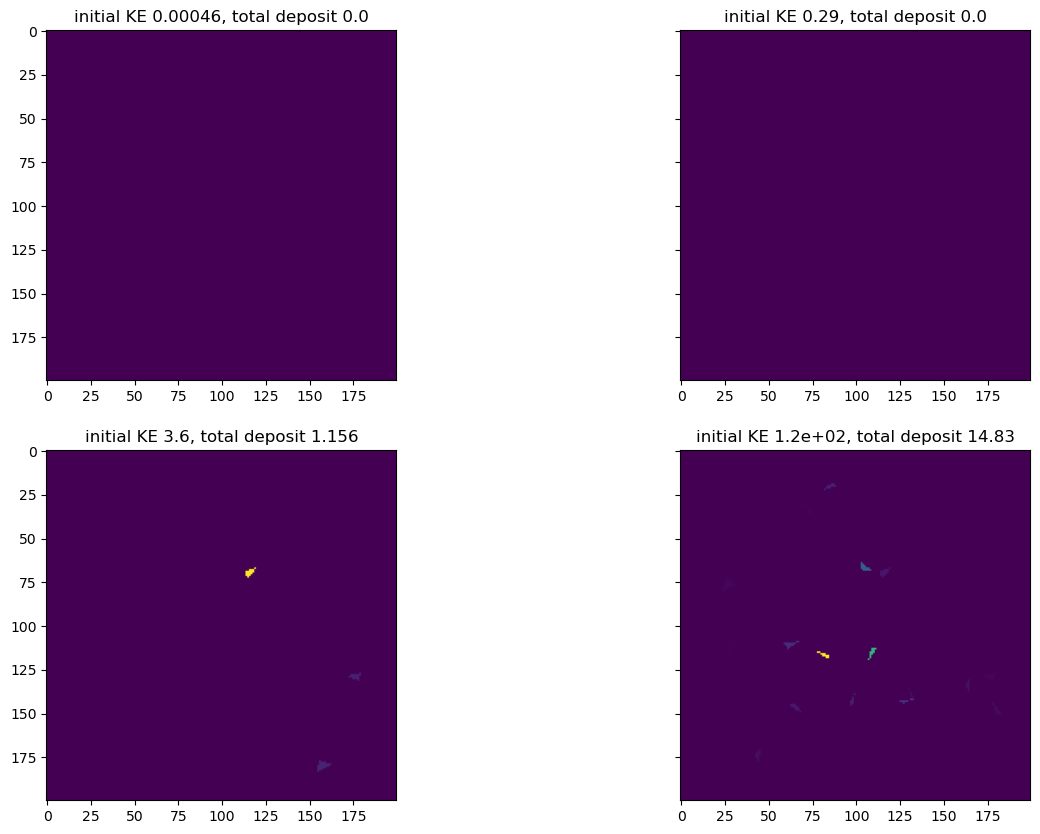

In [10]:
if not skip_long:
    fig, axarr = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
    
    flat_edges = triangles.edges.reshape((-1, 3))
    for i, ke in enumerate(start_ke):
        ax = axarr.flatten()[i]
        energy_per_detector = deposits[i]
        energy_grid = np.copy(grid).astype(float)
        for j, e in enumerate(energy_per_detector):
            energy_grid[grid==(j+1)] = e
        ax.set_title(f"initial KE {ke:.2}, total deposit {energy_per_detector.sum():.4}")
        ax.imshow(energy_grid)
        

[ -5597.10611604 -12890.36483126   1403.75      ]


array([ -5647.10611604,  -5447.10611604, -12970.36483126, -12770.36483126])

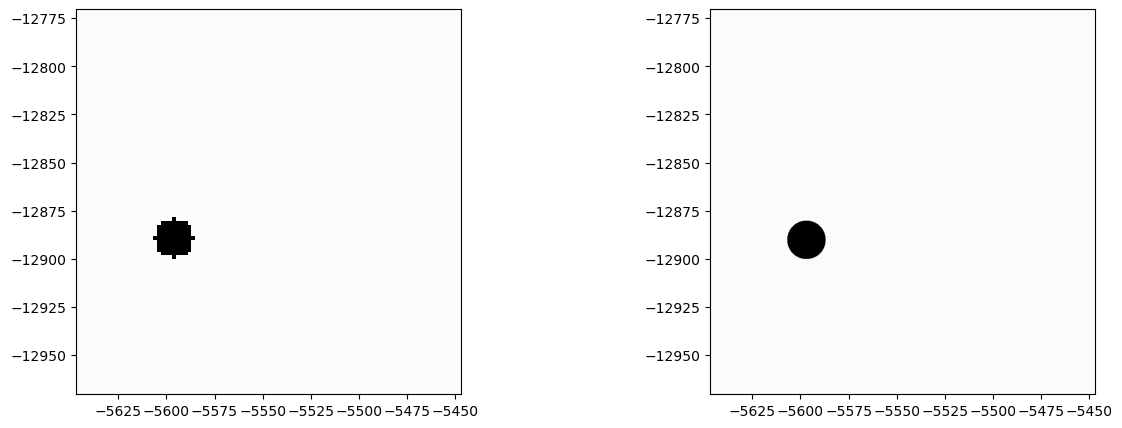

In [11]:
pierre_auger = detector.generate_pierre_auger()
grid_size = 200
fig, axarr = plt.subplots(1, 2, figsize=(15, 5))

center = np.copy(pierre_auger.centers[0])
print(center)
center[1] += 20
center[0] += 50

plt.sca(axarr[0])
plot_grid(*detector.grid_positions(pierre_auger, bins=100, grid_size=grid_size, grid_center=center),cmap='gist_earth_r')
plt.sca(axarr[1])
plot_grid(*detector.grid_positions(pierre_auger, bins=1000, grid_size=grid_size, grid_center=center),cmap='gist_earth_r')


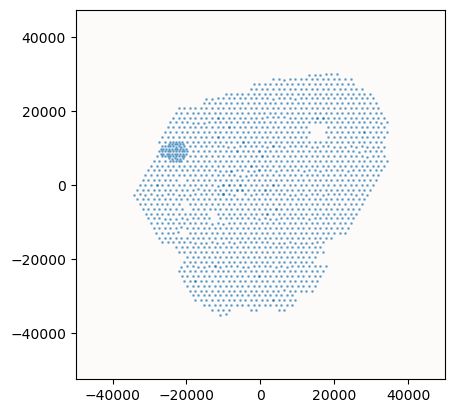

In [12]:
grid_size = 100_000
extent = plot_grid(*detector.grid_positions(pierre_auger, bins=3000, grid_size=grid_size), cmap='gist_earth_r')

def add_scatter(sensitive_regions, extent, energy_per_region=None, **kwargs):
    xs, ys = np.copy(sensitive_regions.centers[:, 0]), np.copy(sensitive_regions.centers[:, 1])

    mask = (xs < extent[1]) * (xs > extent[0]) * (ys < extent[3]) * (ys > extent[2])
    if energy_per_region is None:
        c=None
    else:
        c=energy_per_region[mask]
        print(f"Total colour {c.sum()}")
        if np.all(c==0):
            c[:] = 1
        elif np.any(c==0):
            c[c==0] = 0.01*np.min(c[c>0])
        kwargs['norm']=matplotlib.colors.LogNorm()
        
    plt.scatter(xs[mask], ys[mask], c=c, **kwargs)

add_scatter(pierre_auger, extent, alpha=0.5, s=1)

225 Got deposits, 0.00019511794380377978
185 Got deposits, 3.358952653798042e-06
148 Got deposits, 0.0
6 Got deposits, 0.0


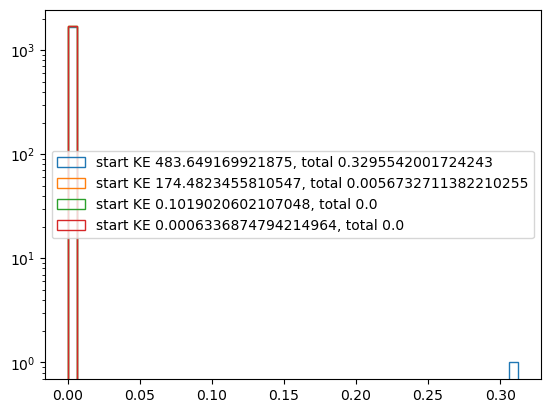

In [16]:
if not skip_long:
    to_plot = [int(np.floor(p*(n_subshowers-1))) for p in [0.1, 0.5, 0.9, 1]]
    to_plot = np.argsort(start_energy)[to_plot][::-1]
    deposits = []
    start_ke = []
    n_leaves = []
    
    for subshower_idx in to_plot:
        start_idx, subshower_leaves = outputs.subshowers[subshower_idx]
        energy_per_detector = responses.sample_energy(reader, subshower_leaves, pierre_auger)
        deposits.append(energy_per_detector)
        print(f"{subshower_idx} Got deposits, {energy_per_detector.mean()}")
        start_ke.append(reader.data["kinetic_energy"][start_idx])
        n_leaves.append(len(subshower_leaves))
    deposits = np.array(deposits)
    bins = np.linspace(0, np.max(deposits), 50)
    for i, energy_per_detector in enumerate(deposits):
        plt.hist(energy_per_detector, histtype='step', bins=bins, label=f"start KE {start_ke[i]}, total {np.sum(energy_per_detector)}")
    plt.legend()
    plt.semilogy()

Total colour 0.3295542001724243
Total colour 0.0056732711382210255
Total colour 0.0
Total colour 0.0


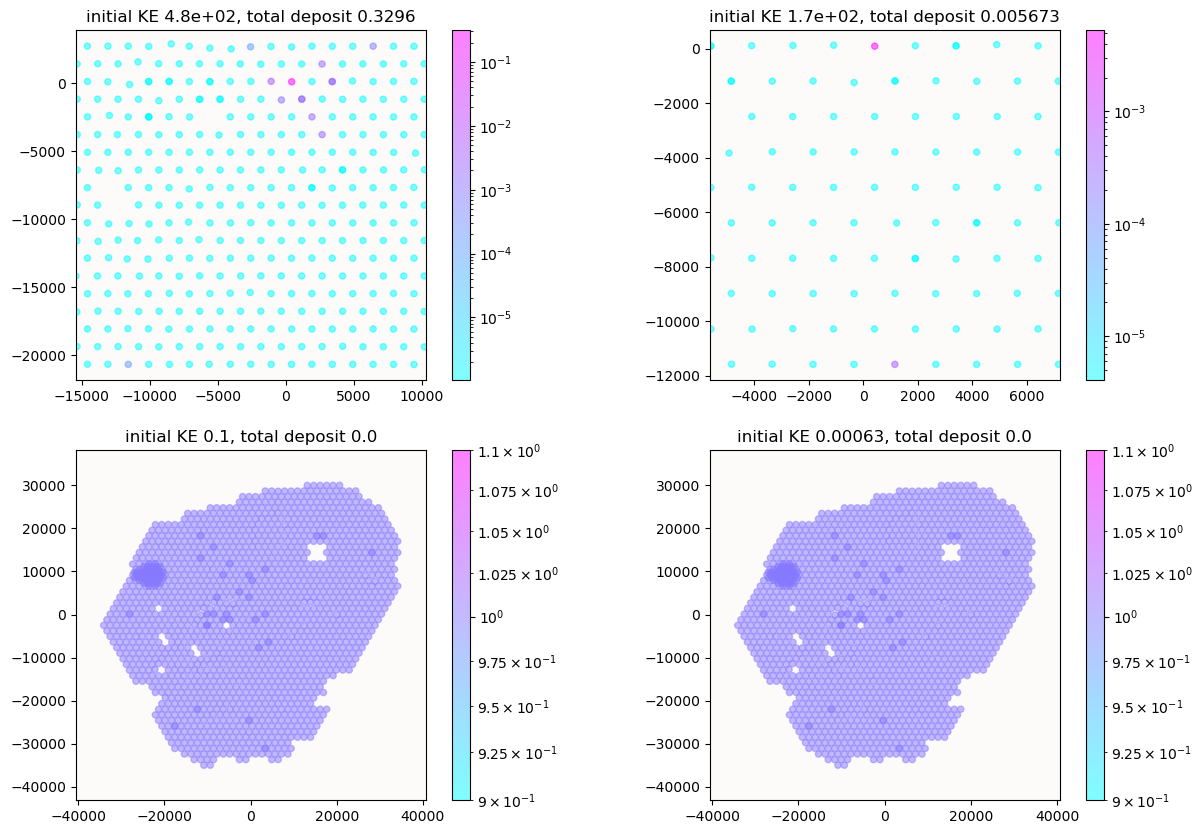

In [17]:
if not skip_long:
    fig, axarr = plt.subplots(2, 2, figsize=(15, 10))
    
    for i, ke in enumerate(start_ke):
        ax = axarr.flatten()[i]
        plt.sca(ax)
        energy_per_detector = deposits[i]
        grid_center, grid_size = detector.center_and_size(pierre_auger, energy_per_detector)

        grid_pa, grid_center, grid_size = detector.grid_positions(pierre_auger, bins=1000, grid_size=grid_size, grid_center=grid_center)

        energy_grid = np.copy(grid_pa).astype(float)
        for j, e in enumerate(energy_per_detector):
            energy_grid[grid_pa==(j+1)] = e
        ax.set_title(f"initial KE {ke:.2}, total deposit {energy_per_detector.sum():.4}")

        extent = plot_grid(energy_grid, grid_center, grid_size, cmap='gist_earth_r')
        add_scatter(pierre_auger, extent, energy_per_detector, alpha=0.5, s=20,cmap='cool')
        plt.colorbar()


In [11]:
np.mean(pierre_auger.centers, axis=0), np.std(pierre_auger.centers, axis=0)

(array([-4.61801454e-12, -1.61561583e-09,  1.41832202e+03]),
 array([16542.28045968, 16102.82674273,    60.05513081]))